In [1]:
import glob
import json
import random
from collections import namedtuple

import pandas as pd
import numpy as np
import scipy.stats as ss

import matplotlib.pyplot as plt

%matplotlib inline

np.random.seed(42)

In [2]:
data = pd.concat([
    pd.read_json(data_path, lines=True) 
    for data_path 
    in glob.glob("/Users/n.anokhin/Desktop/data/*/data.json")
])
data["rnd"] = np.random.random(len(data))

data.head(10)

,message,timestamp,user,track,time,latency,recommendation,experiments,rnd
0,next,2025-08-31 19:29:16.536,1160,1023,0.75,0.002898,3423.0,{'AA': 'C'},0.374540
1,next,2025-08-31 19:29:16.589,5320,12144,0.05,0.000892,1047.0,{'AA': 'T1'},0.950714
2,next,2025-08-31 19:29:16.622,6986,3228,0.07,0.000562,5468.0,{'AA': 'C'},0.731994
3,next,2025-08-31 19:29:16.654,7359,14109,0.25,0.001194,12943.0,{'AA': 'T1'},0.598658
4,next,2025-08-31 19:29:16.673,7359,5658,0.16,0.000533,495.0,{'AA': 'T1'},0.156019
5,next,2025-08-31 19:29:16.696,4070,13772,0.73,0.000640,2094.0,{'AA': 'C'},0.155995
6,last,2025-08-31 19:29:16.709,2972,2904,0.14,0.000224,NaN,{'AA': 'T1'},0.058084
7,next,2025-08-31 19:29:16.731,9421,14841,0.02,0.000576,15254.0,{'AA': 'C'},0.866176
8,next,2025-08-31 19:29:16.748,5349,9027,0.84,0.000681,5835.0,{'AA': 'T1'},0.601115
9,next,2025-08-31 19:29:16.762,443,7236,0.01,0.000563,16081.0,{'AA': 'C'},0.708073


## Compute track popularity

In [3]:
track_popularity = (
    data[data["rnd"] > 0.5]
    .groupby("track")["time"]
    .sum()
    .to_frame()
    .sort_values("time", ascending=False)
    .reset_index()
)

track_popularity.head()

,track,time
0,173,131.71
1,1358,125.27
2,1337,123.19
3,1453,116.40
4,1342,100.91


In [4]:
len(track_popularity)

16198

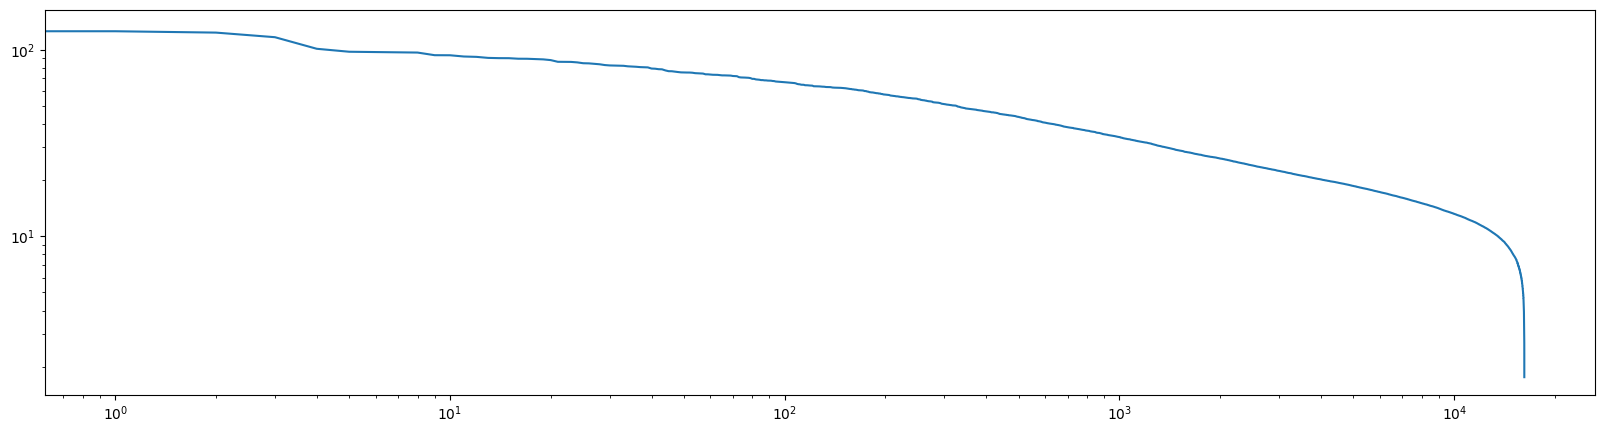

In [5]:
fig, ax = plt.subplots(figsize=(20, 5))

ax.plot(track_popularity.index.values, track_popularity["time"].values)

ax.set_xscale("log")
ax.set_yscale("log")

pass

## Compute offline metrics

In [6]:
# recommendations - список рекомендованных track id от лучшего к худшему
# track           - id трека, который выбрал пользователь
# k               - k в precision@K


def precision_at(recommendations, track, k):
    return 1.0 / k * int(track in recommendations[:k])


    
def shuffled_precision_at(recommendations, track, k):
    shuffled = list(recommendations)
    random.shuffle(shuffled)
    return precision_at(shuffled, track, k)

In [7]:
tracks = track_popularity["track"].tolist()

t_p_10 = lambda track: precision_at(tracks, track, 10)
st_10_p_10 = lambda track: shuffled_precision_at(tracks[:10], track, 10)
st_100_p_10 = lambda track: shuffled_precision_at(tracks[:100], track, 10)
st_1000_p_10 = lambda track: shuffled_precision_at(tracks[:1000], track, 10)


metrics = data[(data["rnd"] <= 0.5) & (data["time"] >= 0.75)].copy()

metrics["top10_PrecAt10"] = metrics["track"].map(t_p_10)
metrics["shuffledTop10_PrecAt10"] = metrics["track"].map(st_10_p_10)
metrics["shuffledTop100_PrecAt10"] = metrics["track"].map(st_100_p_10)
metrics["shuffledTop1000_PrecAt10"] = metrics["track"].map(st_1000_p_10)

metrics[["top10_PrecAt10", "shuffledTop10_PrecAt10", "shuffledTop100_PrecAt10", "shuffledTop1000_PrecAt10"]].describe()

,top10_PrecAt10,shuffledTop10_PrecAt10,shuffledTop100_PrecAt10,shuffledTop1000_PrecAt10
count,144972.000000,144972.000000,144972.000000,144972.000000
mean,0.000713,0.000713,0.000482,0.000287
std,0.008415,0.008415,0.006927,0.005349
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000
max,0.100000,0.100000,0.100000,0.100000


In [8]:
def mrr(recommendations, track):
    return 1.0 / (1 + recommendations.index(track)) if track in recommendations else 0.0

    
def shuffled_mrr(recommendations, track):
    shuffled = list(recommendations)
    random.shuffle(shuffled)
    return mrr(shuffled, track)

In [9]:
tracks = track_popularity["track"].tolist()

t_mrr = lambda track: mrr(tracks, track)
st_10_mrr = lambda track: shuffled_mrr(tracks[:10], track)
st_100_mrr = lambda track: shuffled_mrr(tracks[:100], track)
st_1000_mrr = lambda track: shuffled_mrr(tracks[:1000], track)

metrics = data[(data["rnd"] <= 0.5) & (data["time"] >= 0.75)].copy()

metrics["top10_mrr"] = metrics["track"].map(t_mrr)
metrics["shuffledTop10_mrr"] = metrics["track"].map(st_10_mrr)
metrics["shuffledTop100_mrr"] = metrics["track"].map(st_100_mrr)
metrics["shuffledTop1000_mrr"] = metrics["track"].map(st_1000_mrr)

metrics[["top10_mrr", "shuffledTop10_mrr", "shuffledTop100_mrr", "shuffledTop1000_mrr"]].describe()

,top10_mrr,shuffledTop10_mrr,shuffledTop100_mrr,shuffledTop1000_mrr
count,144972.000000,144972.000000,144972.000000,144972.000000
mean,0.004209,0.002138,0.002579,0.001971
std,0.036946,0.033816,0.029327,0.021307
min,0.000062,0.000000,0.000000,0.000000
25%,0.000122,0.000000,0.000000,0.000000
50%,0.000287,0.000000,0.000000,0.000000
75%,0.001034,0.000000,0.000000,0.001019
max,1.000000,1.000000,1.000000,1.000000


## Export data for prod

In [11]:
BOTIFY_DATA_DIR = "/Users/n.anokhin/Projects/recsys-course/botify/data/"

In [12]:
with open(BOTIFY_DATA_DIR + "top_tracks.json", "w") as top_tracks_file:
    json.dump(track_popularity["track"].tolist(), top_tracks_file)

In [13]:
track_popularity["track"].tolist()

[173,
 1358,
 1337,
 1453,
 1342,
 1633,
 1369,
 626,
 1461,
 3810,
 8172,
 8141,
 8136,
 1260,
 179,
 1638,
 8344,
 1177,
 1439,
 1836,
 491,
 175,
 8140,
 1448,
 8137,
 1454,
 1345,
 8807,
 8360,
 171,
 3803,
 6629,
 1632,
 16,
 1173,
 4397,
 3821,
 978,
 1340,
 1467,
 1754,
 8014,
 3804,
 3877,
 7,
 1493,
 1457,
 1150,
 1684,
 1176,
 1368,
 8254,
 1673,
 1634,
 1403,
 1264,
 684,
 176,
 1261,
 172,
 177,
 174,
 6840,
 7062,
 1635,
 1341,
 1486,
 509,
 1530,
 1719,
 178,
 1744,
 34,
 1378,
 1262,
 9199,
 8029,
 2,
 1463,
 8117,
 1258,
 8818,
 1352,
 5267,
 1263,
 1256,
 541,
 1265,
 326,
 10874,
 1172,
 1371,
 8138,
 676,
 2924,
 4141,
 490,
 1259,
 9153,
 13786,
 16014,
 3819,
 13438,
 8139,
 518,
 13408,
 8116,
 11,
 4161,
 1156,
 8814,
 12225,
 9380,
 13406,
 3949,
 9397,
 1455,
 910,
 180,
 1157,
 918,
 4058,
 15248,
 7066,
 1443,
 39,
 1637,
 91,
 64,
 1451,
 1446,
 8691,
 213,
 10879,
 1867,
 1169,
 81,
 12164,
 24,
 2554,
 1346,
 8115,
 170,
 8062,
 1334,
 1370,
 13591,
 1123,